# Exploration et nettoyage de `application_train.csv` et `application_test.csv`

Cette première exploration vérifie uniquement la structure générale du jeu de données, l'identifiant `SK_ID_CURR`, la cible `TARGET`, les valeurs manquantes et les doublons.

In [87]:
from pathlib import Path

import pandas as pd

# ---------- Chargement des données ----------
DATA_PATH = Path("../data/raw/application_train.csv")

if not DATA_PATH.is_file():
    raise FileNotFoundError(f"Fichier introuvable : {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)

## Dimensions et aperçu

In [88]:
print(f"Nombre de lignes : {df.shape[0]:,}")
print(f"Nombre de colonnes : {df.shape[1]}")
df.head()

Nombre de lignes : 307,511
Nombre de colonnes : 122


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## Vérification de `SK_ID_CURR`

Un identifiant valide doit être présent, sans valeur manquante et unique pour chaque ligne.

In [89]:
ID_COLUMN = "SK_ID_CURR"

if ID_COLUMN not in df.columns:
    raise KeyError(f"Colonne obligatoire absente : {ID_COLUMN}")

verification_id = pd.Series(
    {
        "valeurs_manquantes": int(df[ID_COLUMN].isna().sum()),
        "valeurs_uniques": int(df[ID_COLUMN].nunique()),
        "identifiants_dupliques": int(df[ID_COLUMN].duplicated().sum()),
        "identifiant_unique_par_ligne": bool(df[ID_COLUMN].is_unique),
    },
    name=ID_COLUMN,
)
verification_id.to_frame("résultat")

,résultat
valeurs_manquantes,0
valeurs_uniques,307511
identifiants_dupliques,0
identifiant_unique_par_ligne,True


## Analyse de `TARGET`

La cible est contrôlée puis sa répartition est présentée en effectifs et en pourcentages.

In [90]:
TARGET_COLUMN = "TARGET"

if TARGET_COLUMN not in df.columns:
    raise KeyError(f"Colonne obligatoire absente : {TARGET_COLUMN}")

effectifs = df[TARGET_COLUMN].value_counts(dropna=False).sort_index()
repartition_target = pd.DataFrame(
    {
        "effectif": effectifs,
        "pourcentage": (effectifs / len(df) * 100).round(2),
    }
)
repartition_target.index.name = TARGET_COLUMN
repartition_target

,effectif,pourcentage
TARGET,,
0,282686,91.93
1,24825,8.07


## Valeurs manquantes

Le tableau affiche uniquement les colonnes qui contiennent au moins une valeur manquante.

In [91]:
nombre_manquantes = df.isna().sum()
valeurs_manquantes = pd.DataFrame(
    {
        "nombre de valeurs manquantes": nombre_manquantes,
        "pourcentage": (nombre_manquantes / len(df) * 100).round(2),
    }
)
valeurs_manquantes = valeurs_manquantes.loc[valeurs_manquantes["nombre de valeurs manquantes"] > 0]
valeurs_manquantes = valeurs_manquantes.sort_values("pourcentage", ascending=False)

print(f"Colonnes avec des valeurs manquantes : {len(valeurs_manquantes)} / {df.shape[1]}")
valeurs_manquantes

Colonnes avec des valeurs manquantes : 67 / 122


,nombre de valeurs manquantes,pourcentage
COMMONAREA_MEDI,214865,69.87
COMMONAREA_MODE,214865,69.87
COMMONAREA_AVG,214865,69.87
NONLIVINGAPARTMENTS_MODE,213514,69.43
NONLIVINGAPARTMENTS_MEDI,213514,69.43
...,...,...
EXT_SOURCE_2,660,0.21
AMT_GOODS_PRICE,278,0.09
AMT_ANNUITY,12,0.00
CNT_FAM_MEMBERS,2,0.00


## Doublons

Cette vérification recherche les lignes entièrement identiques.

In [92]:
nombre_doublons = int(df.duplicated().sum())
pourcentage_doublons = nombre_doublons / len(df) * 100

print(f"Nombre de lignes dupliquées : {nombre_doublons:,}")
print(f"Pourcentage de lignes dupliquées : {pourcentage_doublons:.2f} %")

Nombre de lignes dupliquées : 0
Pourcentage de lignes dupliquées : 0.00 %


## Types de données

In [93]:
types_par_colonne = df.dtypes.rename("type").to_frame()
display(types_par_colonne)

print("Résumé par type :")
display(df.dtypes.value_counts().rename("nombre_de_colonnes").to_frame())

,type
SK_ID_CURR,int64
TARGET,int64
NAME_CONTRACT_TYPE,str
CODE_GENDER,str
FLAG_OWN_CAR,str
...,...
AMT_REQ_CREDIT_BUREAU_DAY,float64
AMT_REQ_CREDIT_BUREAU_WEEK,float64
AMT_REQ_CREDIT_BUREAU_MON,float64
AMT_REQ_CREDIT_BUREAU_QRT,float64


Résumé par type :


,nombre_de_colonnes
float64,65
int64,41
str,16


In [94]:
# ---------- Détail des colonnes textuelles ----------
colonnes_texte = df.select_dtypes(include=["object", "string"]).columns

informations_colonnes_texte = pd.DataFrame(
    {
        "type": df[colonnes_texte].dtypes.astype(str),
        "nombre de valeurs uniques": df[colonnes_texte].nunique(dropna=True),
        "aperçu des valeurs": [
            df[colonne].dropna().unique()[:5].tolist()
            for colonne in colonnes_texte
        ],
    }
)
informations_colonnes_texte.index.name = "colonne"
informations_colonnes_texte

,type,nombre de valeurs uniques,aperçu des valeurs
colonne,,,
NAME_CONTRACT_TYPE,str,2,"[Cash loans, Revolving loans]"
CODE_GENDER,str,3,"[M, F, XNA]"
FLAG_OWN_CAR,str,2,"[N, Y]"
FLAG_OWN_REALTY,str,2,"[Y, N]"
NAME_TYPE_SUITE,str,7,"[Unaccompanied, Family, Spouse, partner, Child..."
NAME_INCOME_TYPE,str,8,"[Working, State servant, Commercial associate,..."
NAME_EDUCATION_TYPE,str,5,"[Secondary / secondary special, Higher educati..."
NAME_FAMILY_STATUS,str,6,"[Single / not married, Married, Civil marriage..."
NAME_HOUSING_TYPE,str,6,"[House / apartment, Rented apartment, With par..."


In [95]:
# ---------- Modalités de certaines colonnes textuelles ----------
colonnes_a_detailler = [
    "ORGANIZATION_TYPE",
    "OCCUPATION_TYPE",
    "NAME_FAMILY_STATUS",
]

colonnes_absentes = [
    colonne for colonne in colonnes_a_detailler if colonne not in df.columns
]
if colonnes_absentes:
    raise KeyError(f"Colonnes absentes : {colonnes_absentes}")

for colonne in colonnes_a_detailler:
    print(f"{colonne} :")
    modalites = (
        df[colonne]
        .value_counts(dropna=False)
        .rename_axis("valeur")
        .reset_index(name="effectif")
    )
    display(modalites)

ORGANIZATION_TYPE :


,valeur,effectif
0,Business Entity Type 3,67992
1,XNA,55374
2,Self-employed,38412
3,Other,16683
4,Medicine,11193
5,Business Entity Type 2,10553
6,Government,10404
7,School,8893
8,Trade: type 7,7831
9,Kindergarten,6880


OCCUPATION_TYPE :


,valeur,effectif
0,NaN,96391
1,Laborers,55186
2,Sales staff,32102
3,Core staff,27570
4,Managers,21371
5,Drivers,18603
6,High skill tech staff,11380
7,Accountants,9813
8,Medicine staff,8537
9,Security staff,6721


NAME_FAMILY_STATUS :


,valeur,effectif
0,Married,196432
1,Single / not married,45444
2,Civil marriage,29775
3,Separated,19770
4,Widow,16088
5,Unknown,2


## Préparation de `application_test.csv`

Le jeu de test est chargé et comparé a train.

In [96]:
# ---------- Chargement des données de test ----------
DATA_TEST_PATH = Path("../data/raw/application_test.csv")

if not DATA_TEST_PATH.is_file():
    raise FileNotFoundError(f"Fichier introuvable : {DATA_TEST_PATH.resolve()}")

df_test = pd.read_csv(DATA_TEST_PATH)

print(f"Nombre de lignes : {df_test.shape[0]:,}")
print(f"Nombre de colonnes : {df_test.shape[1]}")
df_test.head()

Nombre de lignes : 48,744
Nombre de colonnes : 121


,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [97]:
# ---------- Vérification des colonnes ----------
colonnes_train_sans_cible = df.columns.drop(TARGET_COLUMN).tolist()

if set(df_test.columns) != set(colonnes_train_sans_cible):
    raise ValueError("Les colonnes du train et du test sont différentes.")

df_test = df_test[colonnes_train_sans_cible]

print("Le train et le test possèdent les mêmes variables explicatives.")

Le train et le test possèdent les mêmes variables explicatives.


## Detection et gestion des outliers

Au départ, la méthode IQR a été appliquée à l’ensemble des variables numériques. Cette première analyse a signalé 72 colonnes contenant des valeurs potentiellement aberrantes, ce qui était trop large pour être interprété facilement. En observant les résultats, certaines variables discrètes étaient signalées à tort comme problématiques, notamment lorsque Q1 et Q3 étaient identiques.

Une seconde analyse a donc été réalisée en limitant l’IQR aux variables ayant plus de 20 valeurs uniques et un IQR supérieur à 0. Le nombre de colonnes détectées est ainsi passé de 72 à 61. Ce filtrage réduit le bruit, mais reste encore assez large : les valeurs détectées seront donc analysées visuellement avant toute décision de suppression ou de traitement.

In [98]:
# ---------- Détection des valeurs aberrantes ----------
colonnes_numeriques = df.select_dtypes(include="number").columns
colonnes_a_analyser = [
    colonne
    for colonne in colonnes_numeriques
    if colonne not in [ID_COLUMN, TARGET_COLUMN]
    and df[colonne].nunique(dropna=True) > 20
]

resultats_outliers = []

for colonne in colonnes_a_analyser:
    valeurs = df[colonne].dropna()
    q1 = valeurs.quantile(0.25)
    q3 = valeurs.quantile(0.75)
    iqr = q3 - q1

    if iqr == 0:
        continue

    limite_basse = q1 - 1.5 * iqr
    limite_haute = q3 + 1.5 * iqr
    masque_outliers = (valeurs < limite_basse) | (valeurs > limite_haute)
    nombre_outliers = int(masque_outliers.sum())

    resultats_outliers.append(
        {
            "colonne": colonne,
            "limite basse": limite_basse,
            "limite haute": limite_haute,
            "nombre de valeurs aberrantes": nombre_outliers,
            "pourcentage": round(nombre_outliers / len(valeurs) * 100, 2),
        }
    )

tableau_outliers = (
    pd.DataFrame(resultats_outliers)
    .sort_values("pourcentage", ascending=False)
    .reset_index(drop=True)
)
tableau_outliers

,colonne,limite basse,limite haute,nombre de valeurs aberrantes,pourcentage
0,DAYS_EMPLOYED,-6466.500000,3417.500000,72217,23.48
1,NONLIVINGAPARTMENTS_AVG,-0.005850,0.009750,15580,16.57
2,NONLIVINGAPARTMENTS_MEDI,-0.005850,0.009750,15215,16.19
3,NONLIVINGAPARTMENTS_MODE,-0.005850,0.009750,14224,15.13
4,NONLIVINGAREA_MODE,-0.034650,0.057750,18817,13.65
...,...,...,...,...,...
56,EXT_SOURCE_3,-0.076961,1.116667,0,0.00
57,DAYS_ID_PUBLISH,-8167.500000,2148.500000,0,0.00
58,DAYS_BIRTH,-30585.500000,-1509.500000,0,0.00
59,EXT_SOURCE_1,-0.177561,1.186621,0,0.00


### Sélection des variables pour l'analyse visuelle

L'analyse IQR initiale signale un nombre important de variables contenant des valeurs extrêmes. Pour les ratios et variables techniques comme `NONLIVINGAREA_*`, `COMMONAREA_*` ou `LIVINGAPARTMENTS_*`, ces extrêmes sont difficiles à interpréter sans connaissance métier suffisante. Ils représentent des extrêmes statistiques, mais ne peuvent pas être qualifiés d'erreurs à ce stade. Ces variables sont donc conservées sans analyse IQR approfondie.

L'analyse visuelle suivante se concentre sur une sélection manuelle de variables plus interprétables. Les histogrammes montrent la forme des distributions, tandis que les boîtes à moustaches rendent les valeurs extrêmes visibles. Aucune valeur n'est supprimée ou modifiée.

In [99]:
# ---------- Variables retenues pour l'analyse visuelle ----------
variables_outliers = [
    "DAYS_EMPLOYED",
    "OBS_30_CNT_SOCIAL_CIRCLE",
    "OBS_60_CNT_SOCIAL_CIRCLE",
    "AMT_GOODS_PRICE",
    "OWN_CAR_AGE",
    "AMT_INCOME_TOTAL",
    "REGION_POPULATION_RELATIVE",
    "AMT_ANNUITY",
    "AMT_CREDIT",
    "AMT_REQ_CREDIT_BUREAU_YEAR",
    "HOUR_APPR_PROCESS_START",
    "DAYS_REGISTRATION",
    "DAYS_LAST_PHONE_CHANGE",
    "DAYS_ID_PUBLISH",
    "DAYS_BIRTH",
]

variables_absentes = [
    colonne for colonne in variables_outliers if colonne not in df.columns
]
if variables_absentes:
    raise KeyError(f"Variables absentes : {variables_absentes}")

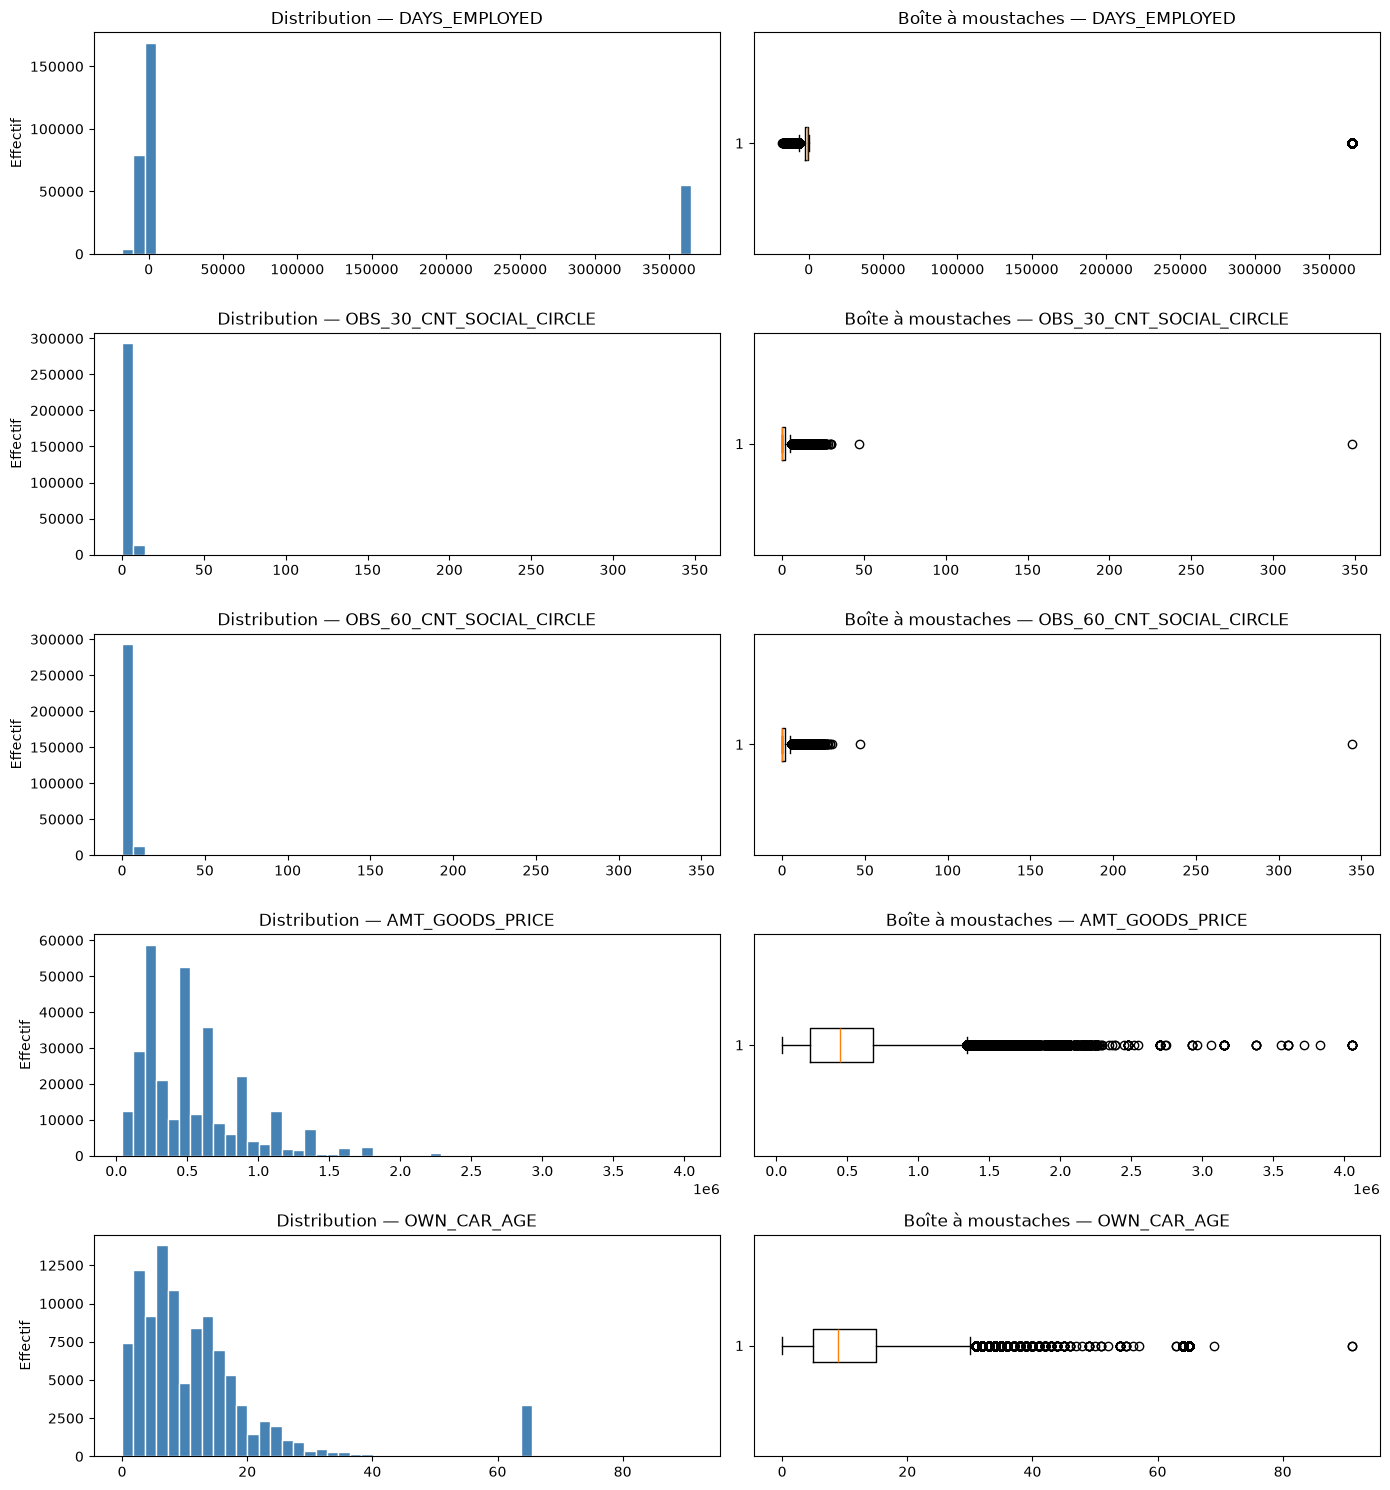

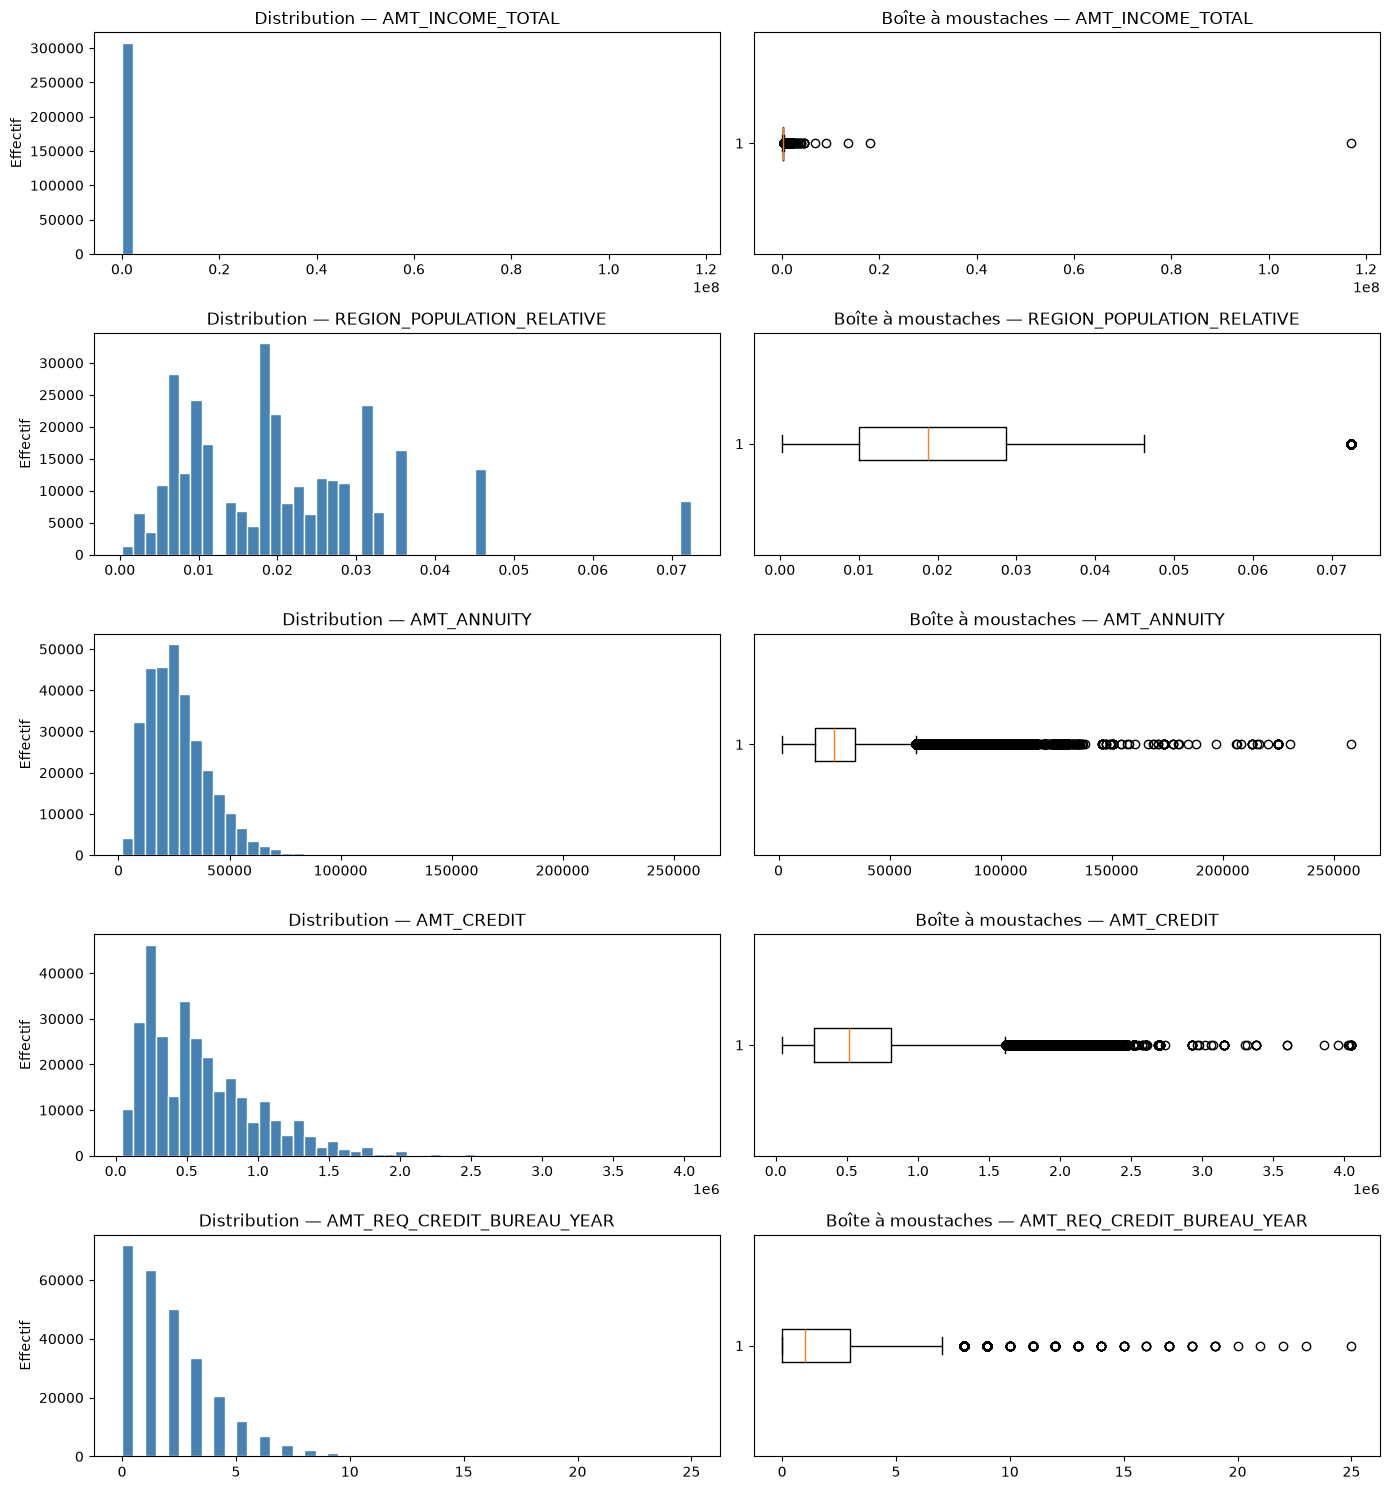

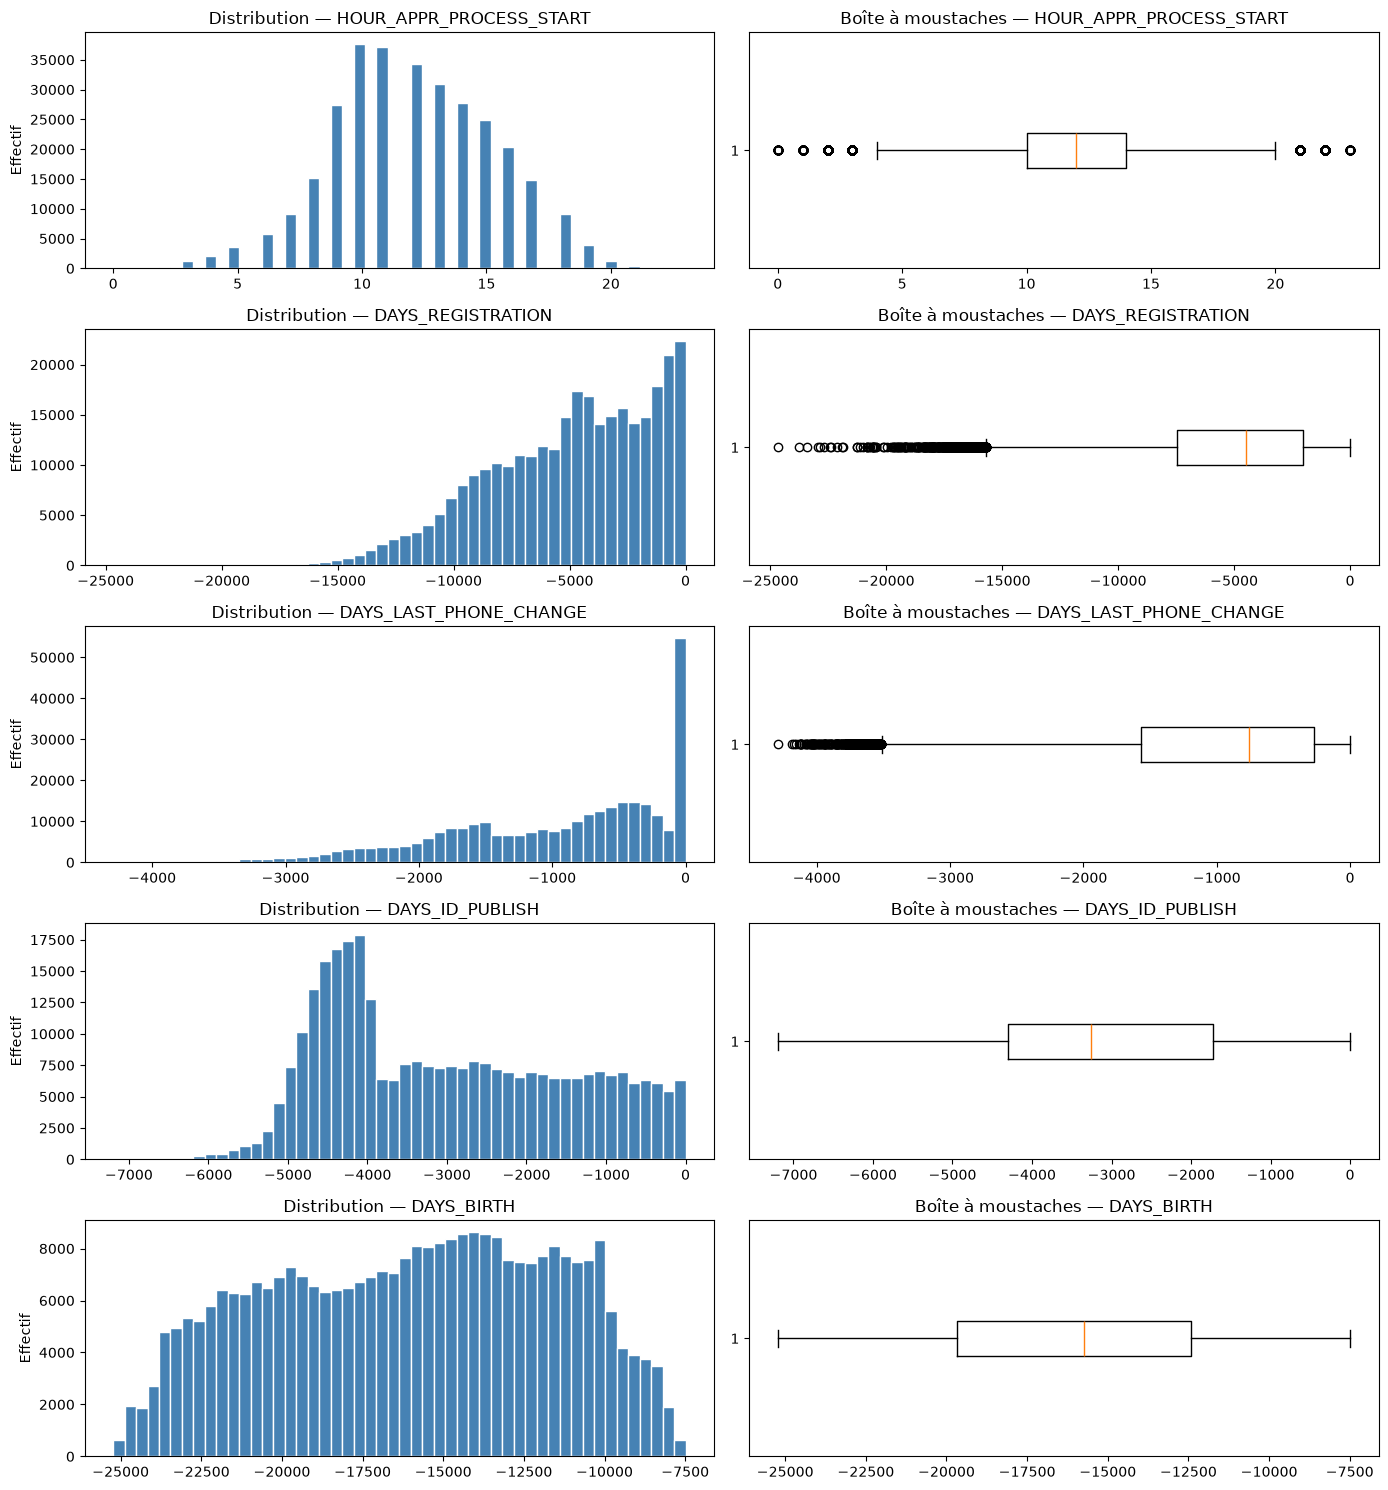

In [100]:
# ---------- Visualisation des distributions et des valeurs extrêmes ----------
import matplotlib.pyplot as plt

TAILLE_GROUPE = 5

for debut in range(0, len(variables_outliers), TAILLE_GROUPE):
    groupe = variables_outliers[debut : debut + TAILLE_GROUPE]
    figure, axes = plt.subplots(
        nrows=len(groupe),
        ncols=2,
        figsize=(14, 3 * len(groupe)),
    )

    for ligne, colonne in enumerate(groupe):
        valeurs = df[colonne].dropna()

        axes[ligne, 0].hist(valeurs, bins=50, color="steelblue", edgecolor="white")
        axes[ligne, 0].set_title(f"Distribution — {colonne}")
        axes[ligne, 0].set_ylabel("Effectif")

        axes[ligne, 1].boxplot(valeurs, orientation="horizontal")
        axes[ligne, 1].set_title(f"Boîte à moustaches — {colonne}")

    figure.tight_layout()
    plt.show()

### Sélection des colonnes les plus problématique suite au graphe et affichage des 10 valeurs les plus haute des ces colonnes 

In [101]:
# ---------- Valeurs les plus élevées ----------
variables_extremes = [
    "AMT_INCOME_TOTAL",
    "OWN_CAR_AGE",
    "OBS_60_CNT_SOCIAL_CIRCLE",
    "OBS_30_CNT_SOCIAL_CIRCLE",
    "DAYS_EMPLOYED",
]

variables_absentes = [
    colonne for colonne in variables_extremes if colonne not in df.columns
]
if variables_absentes:
    raise KeyError(f"Variables absentes : {variables_absentes}")

with pd.option_context("display.max_columns", None):
    for colonne in variables_extremes:
        print(f"10 observations les plus élevées — {colonne}")
        display(
            df.nlargest(10, colonne).reset_index(drop=True)
        )

10 observations les plus élevées — AMT_INCOME_TOTAL


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,114967,1,Cash loans,F,N,Y,1,117000000.0,562491.0,26194.5,454500.0,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.010643,-12615,-922,-6762.0,-3643,NaN,1,1,0,1,0,0,Laborers,3.0,2,2,TUESDAY,14,0,0,0,0,0,0,Business Entity Type 3,0.460809,0.113161,0.145543,0.1031,0.0947,0.9791,NaN,NaN,0.00,0.2069,0.1667,NaN,0.0688,NaN,0.0615,NaN,NaN,0.1050,0.0983,0.9791,NaN,NaN,0.0000,0.2069,0.1667,NaN,0.0704,NaN,0.0641,NaN,NaN,0.1041,0.0947,0.9791,NaN,NaN,0.00,0.2069,0.1667,NaN,0.0700,NaN,0.0626,NaN,NaN,NaN,block of flats,0.0715,"Stone, brick",No,0.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,336147,0,Cash loans,M,Y,Y,2,18000090.0,675000.0,69295.5,675000.0,Unaccompanied,Commercial associate,Secondary / secondary special,Married,House / apartment,0.030755,-15704,-4961,-3338.0,-4728,7.0,1,1,0,1,0,0,NaN,4.0,2,2,THURSDAY,22,0,0,0,0,0,0,Business Entity Type 3,0.543417,0.788606,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,1.0,0.0,-1133.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,385674,0,Cash loans,M,Y,Y,0,13500000.0,1400503.5,130945.5,1368000.0,Unaccompanied,Commercial associate,Higher education,Married,House / apartment,0.030755,-13551,-280,-3953.0,-4972,10.0,1,1,1,1,0,0,NaN,2.0,2,2,SUNDAY,12,0,0,0,0,0,0,Business Entity Type 3,NaN,0.713507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-13.0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,190160,0,Cash loans,F,Y,N,0,90

10 observations les plus élevées — OWN_CAR_AGE


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,415025,1,Cash loans,M,Y,Y,1,180000.0,675000.0,34465.5,675000.0,Unaccompanied,Working,Secondary / secondary special,Married,With parents,0.018209,-9894,-1320,-4675.0,-2559,91.0,1,1,1,1,1,0,Drivers,3.0,3,3,TUESDAY,13,0,0,0,0,0,0,Business Entity Type 3,NaN,0.523138,0.133429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,-688.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,4.0
1,440757,0,Revolving loans,M,Y,N,1,112500.0,180000.0,9000.0,180000.0,Family,Working,Secondary / secondary special,Married,House / apartment,0.018850,-11195,-897,-3582.0,-3691,91.0,1,1,0,1,0,0,Drivers,3.0,2,2,WEDNESDAY,14,0,0,0,0,0,0,Industry: type 4,NaN,0.686340,0.794629,0.0124,0.0250,0.9717,0.6124,NaN,0.00,0.0690,0.0417,NaN,0.0107,0.0092,0.0104,0.0039,0.0241,0.0084,0.0201,0.9697,0.6014,NaN,0.0000,0.0690,0.0417,NaN,0.0106,0.0055,0.0079,0.0000,0.0208,0.0125,0.0250,0.9717,0.6176,NaN,0.00,0.0690,0.0417,NaN,0.0109,0.0094,0.0105,0.0039,0.0246,NaN,block of flats,0.0173,"Stone, brick",No,19.0,0.0,19.0,0.0,-2352.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,1.0,0.0,0.0,2.0
2,287098,0,Cash loans,M,Y,Y,0,315000.0,1125000.0,47794.5,1125000.0,Unaccompanied,Commercial associate,Higher education,Married,House / apartment,0.025164,-18613,-2827,-436.0,-2165,69.0,1,1,0,1,0,1,Managers,2.0,2,2,THURSDAY,12,0,0,0,0,0,0,Business Entity Type 3,0.807885,0.520360,0.712155,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,2.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,2.0
3,100100,0,

10 observations les plus élevées — OBS_60_CNT_SOCIAL_CIRCLE


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,272071,0,Revolving loans,M,N,Y,0,202500.0,180000.0,9000.0,180000.0,Family,State servant,Higher education,Single / not married,House / apartment,0.020246,-10111,-1917,-2306.0,-2306,NaN,1,1,0,1,0,0,Core staff,1.0,3,3,THURSDAY,9,0,0,0,0,1,1,Police,0.360649,0.304506,0.357293,NaN,0.0306,0.9866,0.8164,NaN,0.12,0.0345,0.3333,0.3750,NaN,0.0303,0.0235,NaN,NaN,NaN,0.0317,0.9866,0.8236,NaN,0.1208,0.0345,0.3333,0.3750,NaN,0.0331,0.0245,NaN,NaN,NaN,0.0306,0.9866,0.8189,NaN,0.12,0.0345,0.3333,0.3750,NaN,0.0308,0.0239,NaN,NaN,reg oper account,block of flats,0.0299,Panel,No,348.0,34.0,344.0,24.0,-667.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,1.0,1.0,0.0,3.0
1,189856,0,Cash loans,M,Y,Y,1,157500.0,296280.0,23539.5,225000.0,Family,Working,Secondary / secondary special,Married,House / apartment,0.010147,-14767,-2767,-13306.0,-4720,11.0,1,1,0,1,0,1,Laborers,3.0,2,2,MONDAY,17,0,0,0,0,0,0,Industry: type 4,0.459887,0.398805,0.750375,0.2216,0.1745,0.9816,NaN,NaN,0.24,0.2069,0.3333,NaN,0.1104,NaN,0.2615,NaN,NaN,0.2258,0.1811,0.9816,NaN,NaN,0.2417,0.2069,0.3333,NaN,0.1130,NaN,0.2724,NaN,NaN,0.2238,0.1745,0.9816,NaN,NaN,0.24,0.2069,0.3333,NaN,0.1124,NaN,0.2662,NaN,NaN,NaN,block of flats,0.2057,Panel,No,47.0,0.0,47.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,4.0
2,296470,0,Cash loans,F,N,N,0,99000.0,888840.0,29506.5,675000.0,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.018634,-14862,-2859,-6336.0,-4587,NaN,1,1,0,1,0,0,Accountants,2.0,2,2,MONDAY,10,0,0,0,0,1,1,Bank,0.444227,0.545004,0.766234,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.0,0.0,30.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,

10 observations les plus élevées — OBS_30_CNT_SOCIAL_CIRCLE


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,272071,0,Revolving loans,M,N,Y,0,202500.0,180000.0,9000.0,180000.0,Family,State servant,Higher education,Single / not married,House / apartment,0.020246,-10111,-1917,-2306.0,-2306,NaN,1,1,0,1,0,0,Core staff,1.0,3,3,THURSDAY,9,0,0,0,0,1,1,Police,0.360649,0.304506,0.357293,NaN,0.0306,0.9866,0.8164,NaN,0.12,0.0345,0.3333,0.3750,NaN,0.0303,0.0235,NaN,NaN,NaN,0.0317,0.9866,0.8236,NaN,0.1208,0.0345,0.3333,0.3750,NaN,0.0331,0.0245,NaN,NaN,NaN,0.0306,0.9866,0.8189,NaN,0.12,0.0345,0.3333,0.3750,NaN,0.0308,0.0239,NaN,NaN,reg oper account,block of flats,0.0299,Panel,No,348.0,34.0,344.0,24.0,-667.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,1.0,1.0,0.0,3.0
1,189856,0,Cash loans,M,Y,Y,1,157500.0,296280.0,23539.5,225000.0,Family,Working,Secondary / secondary special,Married,House / apartment,0.010147,-14767,-2767,-13306.0,-4720,11.0,1,1,0,1,0,1,Laborers,3.0,2,2,MONDAY,17,0,0,0,0,0,0,Industry: type 4,0.459887,0.398805,0.750375,0.2216,0.1745,0.9816,NaN,NaN,0.24,0.2069,0.3333,NaN,0.1104,NaN,0.2615,NaN,NaN,0.2258,0.1811,0.9816,NaN,NaN,0.2417,0.2069,0.3333,NaN,0.1130,NaN,0.2724,NaN,NaN,0.2238,0.1745,0.9816,NaN,NaN,0.24,0.2069,0.3333,NaN,0.1124,NaN,0.2662,NaN,NaN,NaN,block of flats,0.2057,Panel,No,47.0,0.0,47.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,4.0
2,296470,0,Cash loans,F,N,N,0,99000.0,888840.0,29506.5,675000.0,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.018634,-14862,-2859,-6336.0,-4587,NaN,1,1,0,1,0,0,Accountants,2.0,2,2,MONDAY,10,0,0,0,0,1,1,Bank,0.444227,0.545004,0.766234,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.0,0.0,30.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,

10 observations les plus élevées — DAYS_EMPLOYED


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100011,0,Cash loans,F,N,Y,0,112500.000,1019610.0,33826.5,913500.0,Children,Pensioner,Secondary / secondary special,Married,House / apartment,0.018634,-20099,365243,-7427.0,-3514,NaN,1,0,0,1,0,0,NaN,2.0,2,2,WEDNESDAY,14,0,0,0,0,0,0,XNA,0.587334,0.205747,0.751724,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,1.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100015,0,Cash loans,F,N,Y,0,38419.155,148365.0,10678.5,135000.0,Children,Pensioner,Secondary / secondary special,Married,House / apartment,0.015221,-20417,365243,-5246.0,-2512,NaN,1,0,0,1,1,0,NaN,2.0,2,2,FRIDAY,7,0,0,0,0,0,0,XNA,0.722044,0.555183,0.652897,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-2396.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,2.0
2,100027,0,Cash loans,F,N,Y,0,83250.000,239850.0,23850.0,225000.0,Unaccompanied,Pensioner,Secondary / secondary special,Married,House / apartment,0.006296,-24827,365243,-9012.0,-3684,NaN,1,0,0,1,1,0,NaN,2.0,3,3,FRIDAY,12,0,0,0,0,0,0,XNA,NaN,0.624305,0.669057,0.1443,0.0848,0.9876,0.8300,0.1064,0.14,0.1207,0.3750,0.4167,0.2371,0.1173,0.1484,0.0019,0.0007,0.1261,0.0754,0.9876,0.8367,0.0000,0.1208,0.1034,0.3750,0.4167,0.2425,0.1102,0.0923,0.0000,0.0000,0.1457,0.0848,0.9876,0.8323,0.1071,0.14,0.1207,0.3750,0.4167,0.2412,0.1193,0.1510,0.0019,0.0007,org spec account,block of flats,0.1640,Mixed,No,0.0,0.0,0.0,0.0,-795.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
3,100045,0,Cash loans,F,N,Y,0,99000.000,2472

### Traitement des anomalies retenues

Les données brutes restent disponibles dans `df`. Les corrections sont appliquées dans `df_clean` avant les encodages. Chaque remplacement par une valeur manquante est accompagné d'un indicateur booléen.

In [102]:
# ---------- Nettoyage des anomalies du train ----------
df_clean = df.copy()

masque_revenu_extreme = df_clean[ID_COLUMN].eq(114967)
if masque_revenu_extreme.sum() != 1:
    raise ValueError("L'observation au revenu extrême n'a pas été trouvée de manière unique.")
df_clean = df_clean.loc[~masque_revenu_extreme].copy()

masques_anomalies_train = {
    "OWN_CAR_AGE": df_clean["OWN_CAR_AGE"] > 60,
    "OBS_30_CNT_SOCIAL_CIRCLE": df_clean["OBS_30_CNT_SOCIAL_CIRCLE"] > 100,
    "OBS_60_CNT_SOCIAL_CIRCLE": df_clean["OBS_60_CNT_SOCIAL_CIRCLE"] > 100,
    "DAYS_EMPLOYED": df_clean["DAYS_EMPLOYED"].eq(365243),
}

for colonne, masque in masques_anomalies_train.items():
    df_clean[f"{colonne}_ANOMALOUS"] = masque
    df_clean[colonne] = df_clean[colonne].astype("Float64")
    df_clean.loc[masque, colonne] = pd.NA

print(f"Lignes supprimées pour AMT_INCOME_TOTAL : {int(masque_revenu_extreme.sum())}")
display(
    pd.Series(
        {colonne: int(masque.sum()) for colonne, masque in masques_anomalies_train.items()},
        name="valeurs remplacées par NaN",
    ).to_frame()
)

Lignes supprimées pour AMT_INCOME_TOTAL : 1


,valeurs remplacées par NaN
OWN_CAR_AGE,3339
OBS_30_CNT_SOCIAL_CIRCLE,1
OBS_60_CNT_SOCIAL_CIRCLE,1
DAYS_EMPLOYED,55374


### Nettoyage des anomalies du test

Les mêmes règles de remplacement par NaN et les mêmes indicateurs booléens sont appliqués au jeu de test.

In [103]:
# ---------- Nettoyage des anomalies du test ----------
df_test_clean = df_test.copy()

masques_anomalies_test = {
    "OWN_CAR_AGE": df_test_clean["OWN_CAR_AGE"] > 60,
    "OBS_30_CNT_SOCIAL_CIRCLE": df_test_clean["OBS_30_CNT_SOCIAL_CIRCLE"] > 100,
    "OBS_60_CNT_SOCIAL_CIRCLE": df_test_clean["OBS_60_CNT_SOCIAL_CIRCLE"] > 100,
    "DAYS_EMPLOYED": df_test_clean["DAYS_EMPLOYED"].eq(365243),
}

for colonne, masque in masques_anomalies_test.items():
    df_test_clean[f"{colonne}_ANOMALOUS"] = masque
    df_test_clean[colonne] = df_test_clean[colonne].astype("Float64")
    df_test_clean.loc[masque, colonne] = pd.NA

display(
    pd.Series(
        {colonne: int(masque.sum()) for colonne, masque in masques_anomalies_test.items()},
        name="valeurs remplacées par NaN",
    ).to_frame()
)

,valeurs remplacées par NaN
OWN_CAR_AGE,460
OBS_30_CNT_SOCIAL_CIRCLE,3
OBS_60_CNT_SOCIAL_CIRCLE,3
DAYS_EMPLOYED,9274


### Conclusion sur les valeurs aberrantes

L'analyse IQR et les visualisations ont permis de distinguer les extrêmes statistiques des anomalies suffisamment plausibles pour justifier un traitement. Les ratios techniques liés au logement, notamment `NONLIVINGAREA_*`, `COMMONAREA_*` et `LIVINGAPARTMENTS_*`, restent inchangés : sans connaissance métier supplémentaire, leurs valeurs extrêmes ne peuvent pas être considérées comme des erreurs.

L'observation `SK_ID_CURR = 114967`, associée à un revenu de 117 000 000 dans `AMT_INCOME_TOTAL`, est retirée du jeu d'entraînement. Les âges de voiture strictement supérieurs à 60 ans dans `OWN_CAR_AGE` sont considérés comme non fiables. Les valeurs strictement supérieures à 100 dans `OBS_30_CNT_SOCIAL_CIRCLE` et `OBS_60_CNT_SOCIAL_CIRCLE` sont également considérées comme anormales en raison de l'écart très important avec le reste des distributions. Enfin, la valeur `365243` de `DAYS_EMPLOYED` est interprétée comme une valeur sentinelle et non comme une durée d'emploi réelle.

Ces anomalies sont remplacées par des valeurs manquantes Nan dans les copies nettoyées du train et du test. Une colonne booléenne `*_ANOMALOUS` conserve, pour chaque variable concernée, l'information qu'une anomalie était initialement présente. Les valeurs manquantes seront imputées lors d'une étape ultérieure. Les fichiers CSV bruts ne sont pas modifiés.

## Encodage des colonnes textuelles binaires

Les colonnes textuelles qui possèdent exactement deux catégories sont encodées en `0` et `1`. Une copie du DataFrame est utilisée pour conserver les données initiales dans `df`.

In [104]:
# ---------- Encodage binaire ----------
df_encoded = df_clean.copy()

colonnes_texte = df_clean.select_dtypes(include=["object", "string"]).columns
colonnes_binaires = [
    colonne
    for colonne in colonnes_texte
    if df_clean[colonne].nunique(dropna=True) == 2
]

correspondances = []
correspondances_binaires = {}

for colonne in colonnes_binaires:
    categories = sorted(df_clean[colonne].dropna().unique().tolist())
    correspondance = {categories[0]: 0, categories[1]: 1}
    correspondances_binaires[colonne] = correspondance
    df_encoded[colonne] = df_encoded[colonne].map(correspondance).astype("Int8")

    correspondances.extend(
        {"colonne": colonne, "catégorie": categorie, "valeur encodée": valeur}
        for categorie, valeur in correspondance.items()
    )

print(f"Colonnes textuelles binaires encodées : {len(colonnes_binaires)}")
display(pd.DataFrame(correspondances))

Colonnes textuelles binaires encodées : 4


,colonne,catégorie,valeur encodée
0,NAME_CONTRACT_TYPE,Cash loans,0
1,NAME_CONTRACT_TYPE,Revolving loans,1
2,FLAG_OWN_CAR,N,0
3,FLAG_OWN_CAR,Y,1
4,FLAG_OWN_REALTY,N,0
5,FLAG_OWN_REALTY,Y,1
6,EMERGENCYSTATE_MODE,No,0
7,EMERGENCYSTATE_MODE,Yes,1


## One-hot encoding des autres colonnes textuelles

Les colonnes qui sont encore textuelles après l'encodage binaire sont transformées en colonnes indicatrices. Les valeurs manquantes disposent d'un indicateur dédié lorsqu'elles sont présentes. Une copie du DataFrame est également utilisé.

In [105]:
# ---------- One-hot encoding ----------
colonnes_texte_restantes = df_encoded.select_dtypes(
    include=["object", "string"]
).columns.tolist()
df_one_hot = pd.get_dummies(
    df_encoded,
    columns=colonnes_texte_restantes,
    prefix_sep="__",
    dummy_na=True,
    dtype="int8",
)

print(f"Colonnes textuelles encodées : {len(colonnes_texte_restantes)}")
print(f"Dimensions avant le one-hot encoding : {df_encoded.shape}")
print(f"Dimensions après le one-hot encoding : {df_one_hot.shape}")
colonnes_texte_restantes

Colonnes textuelles encodées : 12
Dimensions avant le one-hot encoding : (307510, 126)
Dimensions après le one-hot encoding : (307510, 258)


['CODE_GENDER',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'ORGANIZATION_TYPE',
 'FONDKAPREMONT_MODE',
 'HOUSETYPE_MODE',
 'WALLSMATERIAL_MODE']

## Encodage du jeu de test

Les règles apprises sur le train sont appliquées au test, puis les colonnes one-hot sont alignées sur celles du train.

In [106]:
# ---------- Encodage binaire du test ----------
df_test_encoded = df_test_clean.copy()

for colonne, correspondance in correspondances_binaires.items():
    categories_inconnues = (
        set(df_test_clean[colonne].dropna().unique()) - set(correspondance)
    )
    if categories_inconnues:
        raise ValueError(
            f"Catégories inconnues dans {colonne} : {categories_inconnues}"
        )

    df_test_encoded[colonne] = (
        df_test_encoded[colonne].map(correspondance).astype("Int8")
    )

print(f"Colonnes binaires encodées dans le test : {len(correspondances_binaires)}")

Colonnes binaires encodées dans le test : 4


In [107]:
# ---------- One-hot encoding du test ----------
df_test_one_hot = pd.get_dummies(
    df_test_encoded,
    columns=colonnes_texte_restantes,
    prefix_sep="__",
    dummy_na=True,
    dtype="int8",
)

colonnes_finales_train = [
    colonne for colonne in df_one_hot.columns if colonne != TARGET_COLUMN
]
df_test_one_hot = df_test_one_hot.reindex(
    columns=colonnes_finales_train,
    fill_value=0,
)

print(f"Dimensions du train encodé : {df_one_hot.shape}")
print(f"Dimensions du test encodé : {df_test_one_hot.shape}")
print("Les variables explicatives du train et du test sont alignées.")

Dimensions du train encodé : (307510, 258)
Dimensions du test encodé : (48744, 257)
Les variables explicatives du train et du test sont alignées.


## Analyse simple des corrélations

Cette analyse mesure la relation linéaire entre chaque variable explicative et `TARGET` avec le coefficient de Pearson. Le signe indique le sens de la relation et la valeur absolue son intensité. Une corrélation ne démontre pas une relation de causalité.

In [108]:
# ---------- Corrélations avec la cible ----------
donnees_correlation = df_one_hot.drop(columns=[ID_COLUMN])

correlations_target = (
    donnees_correlation
    .corr(numeric_only=True)[TARGET_COLUMN]
    .drop(TARGET_COLUMN)
    .rename("corrélation avec TARGET")
    .to_frame()
)
correlations_target["corrélation absolue"] = (
    correlations_target["corrélation avec TARGET"].abs()
)
correlations_target = correlations_target.sort_values(
    "corrélation absolue",
    ascending=False,
)
correlations_target

,corrélation avec TARGET,corrélation absolue
EXT_SOURCE_3,-0.178898,0.178898
EXT_SOURCE_2,-0.160453,0.160453
EXT_SOURCE_1,-0.155319,0.155319
DAYS_BIRTH,0.078232,0.078232
DAYS_EMPLOYED,0.074952,0.074952
...,...,...
NAME_EDUCATION_TYPE__nan,NaN,NaN
NAME_FAMILY_STATUS__nan,NaN,NaN
NAME_HOUSING_TYPE__nan,NaN,NaN
WEEKDAY_APPR_PROCESS_START__nan,NaN,NaN


### Distribution des 10 variables les plus corrélées selon la cible

Les distributions sont normalisées séparément pour chaque classe afin que le déséquilibre de `TARGET` ne domine pas la comparaison. Ces graphiques montrent des associations avec la cible, mais ne permettent pas de conclure à un effet causal.

,corrélation avec TARGET,corrélation absolue
EXT_SOURCE_3,-0.178898,0.178898
EXT_SOURCE_2,-0.160453,0.160453
EXT_SOURCE_1,-0.155319,0.155319
DAYS_BIRTH,0.078232,0.078232
DAYS_EMPLOYED,0.074952,0.074952
REGION_RATING_CLIENT_W_CITY,0.060894,0.060894
REGION_RATING_CLIENT,0.058901,0.058901
NAME_INCOME_TYPE__Working,0.057472,0.057472
NAME_EDUCATION_TYPE__Higher education,-0.056587,0.056587
DAYS_LAST_PHONE_CHANGE,0.055207,0.055207


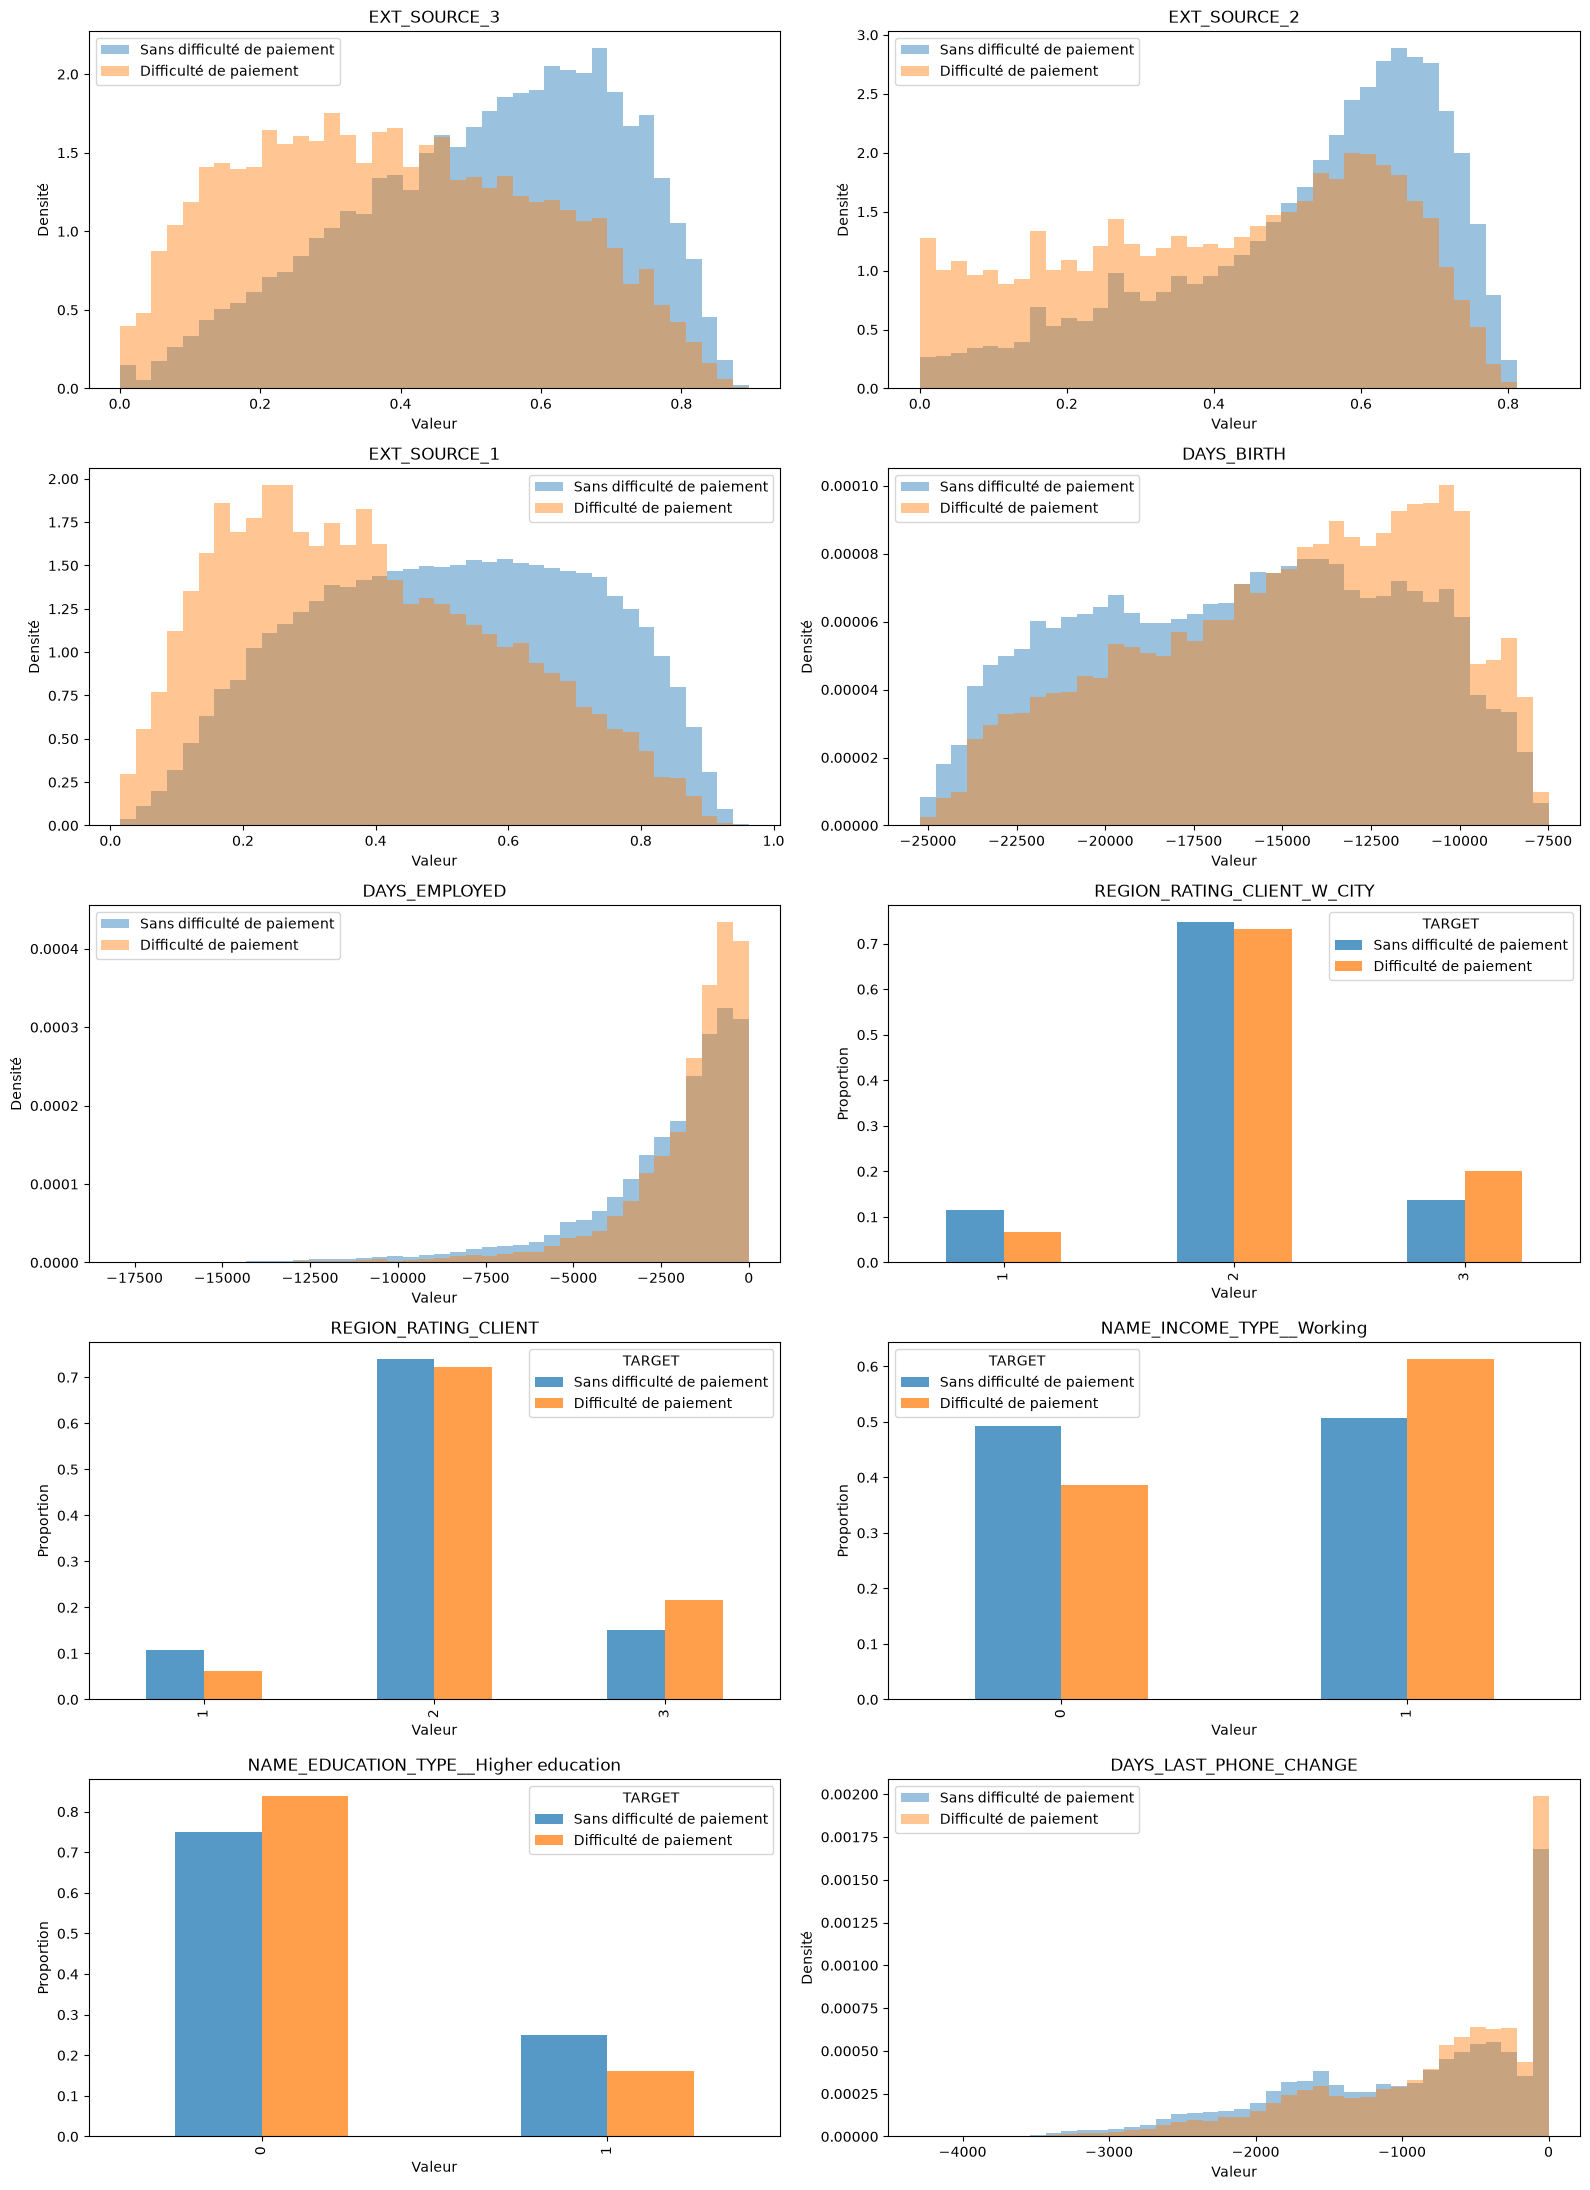

In [109]:
# ---------- Variables les plus corrélées ----------
top_10_features = correlations_target.head(10).index.tolist()
display(correlations_target.loc[top_10_features])

libelles_target = {
    0: "Sans difficulté de paiement",
    1: "Difficulté de paiement",
}

figure, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 22))
axes = axes.flatten()

for axe, colonne in zip(axes, top_10_features):
    nombre_valeurs = df_one_hot[colonne].nunique(dropna=True)

    if nombre_valeurs <= 10:
        proportions = pd.crosstab(
            df_one_hot[colonne],
            df_one_hot[TARGET_COLUMN],
            normalize="columns",
        ).rename(columns=libelles_target)
        proportions.plot(kind="bar", ax=axe, alpha=0.75)
        axe.set_ylabel("Proportion")
    else:
        valeurs = df_one_hot[colonne].dropna()
        minimum, maximum = valeurs.min(), valeurs.max()
        bornes = [minimum + i * (maximum - minimum) / 40 for i in range(41)]

        for target, libelle in libelles_target.items():
            valeurs_classe = df_one_hot.loc[
                df_one_hot[TARGET_COLUMN].eq(target), colonne
            ].dropna()
            axe.hist(
                valeurs_classe,
                bins=bornes,
                density=True,
                alpha=0.45,
                label=libelle,
            )
        axe.set_ylabel("Densité")
        axe.legend()

    axe.set_title(colonne)
    axe.set_xlabel("Valeur")

figure.tight_layout()
plt.show()

## Bilan et validation

Avant l'export, les contrôles suivants vérifient que les identifiants restent uniques, que la cible est réservée au train, que les indicateurs d'anomalie sont présents et que les variables explicatives du train et du test sont parfaitement alignées.

In [ ]:
# ---------- Validation des données finales ----------
colonnes_anomalies = [
    "OWN_CAR_AGE_ANOMALOUS",
    "OBS_30_CNT_SOCIAL_CIRCLE_ANOMALOUS",
    "OBS_60_CNT_SOCIAL_CIRCLE_ANOMALOUS",
    "DAYS_EMPLOYED_ANOMALOUS",
]
colonnes_train_finales = df_one_hot.drop(columns=[TARGET_COLUMN]).columns.tolist()

assert df_clean[ID_COLUMN].is_unique, "Les identifiants du train ne sont pas uniques."
assert df_test_clean[ID_COLUMN].is_unique, "Les identifiants du test ne sont pas uniques."
assert TARGET_COLUMN in df_one_hot.columns, "TARGET est absente du train final."
assert TARGET_COLUMN not in df_test_one_hot.columns, "TARGET est présente dans le test."
assert colonnes_train_finales == df_test_one_hot.columns.tolist(), (
    "Les variables explicatives du train et du test ne sont pas alignées."
)
assert set(colonnes_anomalies).issubset(df_one_hot.columns), (
    "Des indicateurs d'anomalie sont absents du train."
)
assert set(colonnes_anomalies).issubset(df_test_one_hot.columns), (
    "Des indicateurs d'anomalie sont absents du test."
)

display(
    pd.DataFrame(
        {
            "jeu de données": ["train", "test"],
            "nombre de lignes": [len(df_one_hot), len(df_test_one_hot)],
            "nombre de colonnes": [df_one_hot.shape[1], df_test_one_hot.shape[1]],
        }
    )
)
print("Toutes les validations sont réussies.")

### Export des données préparées

Cette cellule crée le dossier `data/processed/` et exporte les jeux train et test nettoyés, encodés et alignés.

In [ ]:
# ---------- Export des données ----------
PROCESSED_DIR = Path("../data/processed")
TRAIN_PROCESSED_PATH = PROCESSED_DIR / "application_train_clean_encoded.csv"
TEST_PROCESSED_PATH = PROCESSED_DIR / "application_test_clean_encoded.csv"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
df_one_hot.to_csv(TRAIN_PROCESSED_PATH, index=False)
df_test_one_hot.to_csv(TEST_PROCESSED_PATH, index=False)

print(f"Train exporté vers : {TRAIN_PROCESSED_PATH.resolve()}")
print(f"Test exporté vers : {TEST_PROCESSED_PATH.resolve()}")

## Conclusion

Ce notebook a permis d'explorer les jeux `application_train.csv` et `application_test.csv`, de documenter et traiter les anomalies retenues, d'encoder les variables textuelles et d'effectuer une première analyse des corrélations avec la cible. Les jeux obtenus possèdent les mêmes variables explicatives et peuvent être exportés dans `data/processed/`.

Le prochain notebook repartira de ces données préparées pour étudier les jointures avec les autres jeux de données, effectuer si nécessaire des nettoyages complémentaires et réaliser le feature engineering.